In [5]:
import numpy as np
import illustris_python as il

In [72]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [6]:
snapnum=40

In [7]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG100-1'

In [8]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [9]:
h = 0.6774

In [17]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [11]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [56]:
mvir_tng_sfr = mvir[group_sfrs>-2]

In [12]:
dir1 = "/cosma7/data/dp004/dc-zhan5/eagle-sfr/mvir/snap17"

In [18]:
ihalo_group, mvir_group, group_sfrs_eagle = np.loadtxt(f"{dir1}/group_sfrs.txt", unpack=True)

In [51]:
ihalo_group, mvir_eagle_all = np.loadtxt(f"{dir1}/group_all.txt", unpack=True)

In [58]:
mhalo_tng1 = mvir
mhalo_eagle1 = mvir_eagle_all

In [97]:
mhalo_tng2 = mvir_tng_sfr
mhalo_eagle2 = mvir_group[group_sfrs_eagle>-2]

In [14]:
boxsize_tng = 75
h_eagle = 0.6777
boxsize_eagle = 100*h_eagle

In [22]:
def halo_mass_function(masses, boxsize, log_M_min=8.0, log_M_max=15.0, delta_log_M=0.1,
                       calculate_err=True):
    nbins = int(1 + (log_M_max - log_M_min)/delta_log_M)
    bins = np.linspace(log_M_min, log_M_max, num=nbins)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    num_halos = np.histogram(masses, bins)[0]

    normalisation = (boxsize**3) * delta_log_M

    if calculate_err:
        # Calculate error bars assuming Poisson distribution in each bin
        errs = np.sqrt(num_halos)/normalisation

    bin_counts = num_halos / normalisation
    
    return bin_centers, bin_counts, errs

    

In [53]:
bin_centers1, bin_counts1, errs1 = halo_mass_function(mhalo_tng1, boxsize_tng, log_M_min=8.0,
                                                  log_M_max=15.0, delta_log_M=0.1)
bin_centers2, bin_counts2, errs2 = halo_mass_function(mhalo_eagle1, boxsize_eagle, log_M_min=8.0,
                                                  log_M_max=15.0, delta_log_M=0.1)

In [98]:
bin_centers1_sfr, bin_counts1_sfr, errs1_sfr = halo_mass_function(mhalo_tng2, boxsize_tng, log_M_min=8.0,
                                                  log_M_max=15.0, delta_log_M=0.1)
bin_centers2_sfr, bin_counts2_sfr, errs2_sfr = halo_mass_function(mhalo_eagle2, boxsize_eagle, log_M_min=8.0,
                                                  log_M_max=15.0, delta_log_M=0.1)

In [90]:

def logging(bin_centers, bin_counts, errs):
    log_bin_center = []
    log_bin_counts = []
    log_up_errs = []
    log_down_errs = []
    one_halo_bin_centers = []
    one_halo_bin_counts = []
    
    for i, m in enumerate(bin_centers):
        if bin_counts[i] > 0:
            if bin_counts[i] == errs[i]:
                one_halo_bin_centers.append(m)
                one_halo_bin_counts.append(np.log10(bin_counts[i]))
                
                log_bin_center.append(np.nan)
                log_bin_counts.append(np.nan)
                log_up_errs.append(np.nan)
                log_down_errs.append(np.nan)
            else:
                log_bin_center.append(m)
                log_bin_counts.append(np.log10(bin_counts[i]))
                up_err = np.log10(bin_counts[i]+errs[i]) - np.log10(bin_counts[i])
                down_err = np.log10(bin_counts[i]) - np.log10(bin_counts[i]-errs[i])
                log_up_errs.append(up_err)
                log_down_errs.append(down_err)
        else:
            log_bin_center.append(np.nan)
            log_bin_counts.append(np.nan)
            log_up_errs.append(np.nan)
            log_down_errs.append(np.nan)
            one_halo_bin_centers.append(np.nan)
            one_halo_bin_counts.append(np.nan)
    return log_bin_center, log_bin_counts, log_up_errs, log_down_errs, one_halo_bin_centers, one_halo_bin_counts


In [92]:
log_bin_centers1, log_bin_counts1, log_up_errs1, log_down_errs1, one_halo_bin_centers1, one_halo_bin_counts1 = logging(bin_centers1, bin_counts1, errs1)
log_bin_centers2, log_bin_counts2, log_up_errs2, log_down_errs2, one_halo_bin_centers2, one_halo_bin_counts2 = logging(bin_centers2, bin_counts2, errs2)

In [99]:
log_bin_centers1_sfr, log_bin_counts1_sfr, log_up_errs1_sfr, log_down_errs1_sfr, one_halo_bin_centers1_sfr, one_halo_bin_counts1_sfr = logging(bin_centers1_sfr, bin_counts1_sfr, errs1_sfr)
log_bin_centers2_sfr, log_bin_counts2_sfr, log_up_errs2_sfr, log_down_errs2_sfr, one_halo_bin_centers2_sfr, one_halo_bin_counts2_sfr = logging(bin_centers2_sfr, bin_counts2_sfr, errs2_sfr)

In [130]:
from colossus.cosmology import cosmology
from colossus.lss import mass_function

def jenkins_hmf(log_bin_centers, z):
    dlog10M = 0.1
    mass1 = 10**np.array(log_bin_centers)
    cosmology.setCosmology('planck15')
    mfunc1 = mass_function.massFunction(mass1, z, mdef = 'vir', model = 'comparat17', #M is in Msun/h
                                           ps_args={"model":"eisenstein98", "path":None}, 
                                            q_in = "M", q_out = 'dndlnM')

    dlnM = np.log(10**dlog10M)
    dndlog10m_colossus1 = []
    for i, dndlnm in enumerate(mfunc1):
        M1 = 10**(np.log10(mass1[i]) - dlog10M/2)
        M2 = 10**(np.log10(mass1[i]) + dlog10M/2)
        dM = M2 - M1
        #print("{:e}".format(dM))
        dndlog10m = dndlnm * dlnM / dlog10M
        dndlog10m_colossus1.append(dndlog10m)
    return dndlog10m_colossus1

In [46]:
import matplotlib.pyplot as plt
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 5)
plt.rcParams["legend.frameon"] = False

plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [95]:
len(log_bin_centers2_sfr)

70

In [96]:
len(ratio2)

70

In [47]:
eagle_dm_mass = 9.70 * 10**6
tng_dm_mass = 7.5 * 10**6

eagle_dm100 = eagle_dm_mass * 100
tng_dm100 = tng_dm_mass * 100

In [48]:
eagle_gas_mass = 1.81 * 10**6
tng_gas_mass = 1.4 * 10**6

eagle_gas100 = eagle_gas_mass * 100
tng_gas100 = tng_gas_mass * 100

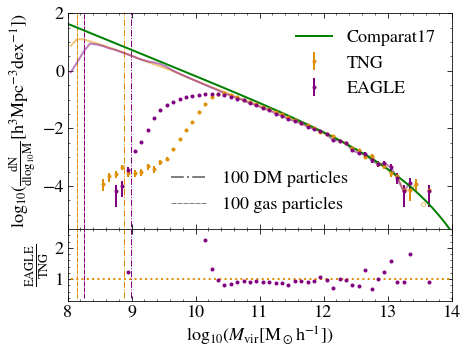

In [132]:
is_gas = True
#Main plot
z=1.5
fig1 = plt.figure()
frame1 = fig1.add_axes((.1,.3,.8,.6))

c_tng = palette_tab10[1]

plt.plot([np.log10(tng_dm100)]*2,[-8, 3], linestyle="dashdot", c = c_tng, linewidth=1)
plt.plot([np.log10(eagle_dm100)]*2,[-8, 3], linestyle="dashdot", c = "purple", linewidth=1)
if is_gas:
    plt.plot([np.log10(tng_gas100)]*2,[-8, 3], linestyle=(0, (5,1)), c = c_tng, linewidth=1)
    plt.plot([np.log10(eagle_gas100)]*2,[-8, 3], linestyle=(0, (5,1)), c = "purple", linewidth=1)

# pinocchio1024 = plt.errorbar(log_bin_centers1, log_bin_counts1, yerr=[log_down_errs1, log_up_errs1], fmt=".",
#             label="TNG", c="orange")
# pinocchio1536 = plt.errorbar(log_bin_centers2, log_bin_counts2, yerr=[log_down_errs2, log_up_errs2], fmt=".",
#             label="EAGLE", c="purple")    

plt.plot(log_bin_centers1, log_bin_counts1, c=c_tng, alpha=0.5)
plt.plot(log_bin_centers2, log_bin_counts2, c="purple",alpha=0.5)
pinocchio1024 = plt.errorbar(log_bin_centers1_sfr, log_bin_counts1_sfr, yerr=[log_down_errs1_sfr, log_up_errs1_sfr], fmt=".",
            label="TNG", c=c_tng)
pinocchio1536 = plt.errorbar(log_bin_centers2_sfr, log_bin_counts2_sfr, yerr=[log_down_errs2_sfr, log_up_errs2_sfr], fmt=".",
            label="EAGLE", c="purple")
jenkins_mass = np.arange(8,15,0.1)
plt.plot(jenkins_mass, np.log10(jenkins_hmf(jenkins_mass, z=z)), label="Comparat17", c="green")
plt.errorbar(one_halo_bin_centers1, one_halo_bin_counts1, fmt="o", c=c_tng, mfc="none", ms=4, mew=0.5)
plt.errorbar(one_halo_bin_centers2, one_halo_bin_counts2, fmt="o", c="purple", mfc="none", ms=4, mew=0.5)
frame1.set_xticklabels([])
plt.ylabel(r"$\rm log_{10}(\frac{dN}{d\log_{10}M} [h^3 Mpc^{-3}dex^{-1}])$", loc="top")

plt.xlim(8, 14)
plt.ylim(-5.5,2)

npart_line_dm = plt.plot([], [], color="grey", linestyle="dashdot", label="100 DM particles")
if is_gas:
    npart_line_gas = plt.plot([], [], color="grey", linestyle=(0, (5,1)), linewidth=1, label="100 gas particles")


#get handles and labels
handles, labels = plt.gca().get_legend_handles_labels()
#specify order of items in legend
if is_gas:
    order = [0,3,4]
else:
    order = [0,2,3]
#add legend to plot
leg1 = plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc="upper right")
if is_gas:
    order = [1, 2]
else:
    order = [1]

leg2 = plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc="lower center")
plt.gca().add_artist(leg1)

#Ratio plot
jenkins1 = jenkins_hmf(log_bin_centers1_sfr, z=z)
jenkins2 = jenkins_hmf(log_bin_centers2_sfr, z=z)
ratio1 = [m/n for m,n in zip(10**np.array(log_bin_counts1_sfr), jenkins1)]
mask2 = np.isin(log_bin_centers1_sfr, log_bin_centers2_sfr)
#ratio2 = [m/n for m,n in zip(10**np.array(log_bin_counts2_sfr), 10**np.array(log_bin_counts1_sfr)[mask2])]
ratio2 = [m/n for m,n in zip(10**np.array(log_bin_counts2_sfr), 10**np.array(log_bin_counts1_sfr))]
frame2 = fig1.add_axes((.1,.1,.8,.2))
#plt.errorbar(log_bin_centers1, ratio1, fmt=".", c="orange")
plt.errorbar(log_bin_centers2_sfr, ratio2, fmt=".", c="purple")
plt.plot([7.8, 15], [1,1], linestyle="dotted", c=c_tng)
ymin = 0.4
ymax = 2.6
plt.plot([np.log10(tng_dm100)]*2,[ymin, ymax], linestyle="dashdot", c =c_tng, linewidth=1)
plt.plot([np.log10(eagle_dm100)]*2,[ymin, ymax], linestyle="dashdot", c ="purple", linewidth=1)

if is_gas:
    plt.plot([np.log10(tng_gas100)]*2,[ymin, ymax], linestyle=(0, (5,1)), c = c_tng, linewidth=1)
    plt.plot([np.log10(eagle_gas100)]*2,[ymin, ymax], linestyle=(0, (5,1)), c = "purple",linewidth=1)

    #plt.plot([np.log10(tng_gas100)]*2,[ymin, ymax], linestyle="dashdot", c = "orange", linewidth=1)
    #plt.plot([np.log10(eagle_gas100)]*2,[ymin, ymax], linestyle=(0, (5,1)), c = "purple",linewidth=1)

#plt.xlabel(r"$\rm log_{10}(M_{\mathrvir} [M_{\odot} h^{-1}])$")
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
plt.ylabel(r"$\rm \frac{EAGLE}{TNG}$")
plt.xlim(8,14)
plt.ylim(0.3, 2.6)
#plt.savefig("../figures/hmf_eagle_vs_tng_logSFR>-2_mvir.pdf", format="pdf", bbox_inches="tight")